# Multi-Layer Perceptron

### Neural Networks

In this notebook, we will train a neural network to predict whether a hotel reservation will be canceled. This allows hotels to better manage their inventory and revenue by identifying "high-risk" bookings before they happen. We use a Multi-Layer Perceptron (MLP) because booking behavior often involves complex, non-linear patterns—like how the combination of a long lead time and a high price might increase the chance of a cancellation more than either factor alone.

Neural networks are known as universal function approximators; they excel here because booking behavior is rarely linear. A guest's decision to cancel often depends on a complex web of factors, like the length of their stay combined with how far in advance they booked, that a standard model might miss.

### Data Acquisition and Inspection

First, we import our primary libraries and load the dataset. Displaying the first few rows ensures our naming conventions are correct and the data is "clean" before we begin training.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# Load the data
# File source: https://www.kaggle.com/datasets/youssefaboelwafa/hotel-booking-cancellation-prediction
df = pd.read_csv("booking.csv")

# clean the data
# We drop non-numeric IDs and categorical columns to keep the MLP input simple
# In this dataset, the target column is 'booking_status' (Canceled/Not_Canceled)
# We convert the target to binary (1 for Canceled, 0 for Not_Canceled)
df['target'] = df['booking status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# drop non-numeric features and the original status column
cols_to_drop = ['Booking_ID', 'type of meal', 'room type',
                'market segment type', 'booking status', 'date of reservation']
df = df.drop(columns=cols_to_drop)
df.dropna(inplace=True)
df


,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,target
0,1,1,2,5,0,224,0,0,0,88.00,0,0
1,1,0,1,3,0,5,0,0,0,106.68,1,0
2,2,1,1,3,0,1,0,0,0,50.00,0,1
3,1,0,0,2,0,211,0,0,0,100.00,1,1
4,1,0,1,2,0,48,0,0,0,77.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
36280,2,0,0,2,0,346,0,0,0,115.00,1,1
36281,2,0,1,3,0,34,0,0,0,107.55,1,0
36282,2,0,1,3,0,83,0,0,0,105.61,1,0
36283,3,0,0,4,0,121,0,0,0,96.90,1,0


### Feature and Data Scaling

Neural networks are highly sensitive to the scale of input data. Features like `average price` can be in the hundreds, while `number of children` might be zero or one. We use `StandardScaler`.
 be zero or one. We use StandardScaler to normalize these so that the model doesn't "over-prioritize" features simply because they have larger numbers

In [15]:
#Separate features and target
X = df.drop(columns="target")
y = df["target"]

# Normalise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Separate training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)



### Building the Multilayer Perceptron

Now, we configure our MLP with two hidden layers: the first with **64 neurons** and the second with **32 neurons**. This depth allows the model to capture high-level interactions between booking features. We use the **ReLU** activation function to introduce non-linearity and the Adam optimizer to handle the mathematical updates of the weights.

In [16]:
# Train the MLP (Multi-Layer Perceptron)
# Using 64 and 32 nodes in hidden layers with ReLU activation
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                      solver='adam', alpha=0.0001, max_iter=200, random_state=42)
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42)

### Evaluating Model Performance

To understand how our model is performing, we look at the Accuracy, Classification Report, and the Confusion Matrix.


Accuracy: 83.85%

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      4879
           1       0.79      0.69      0.74      2378

    accuracy                           0.84      7257
   macro avg       0.82      0.80      0.81      7257
weighted avg       0.84      0.84      0.84      7257



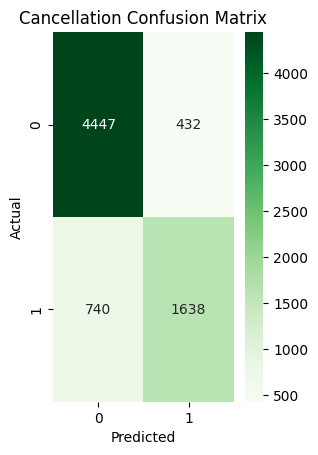

In [17]:
#Evaluate the model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizing results
# plot Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Cancellation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Visualising the ROC curve

While accuracy tells us how many total predictions were right, the ROC-AUC score tells us how well the model distinguishes between "Cancelled" and "Stayed."

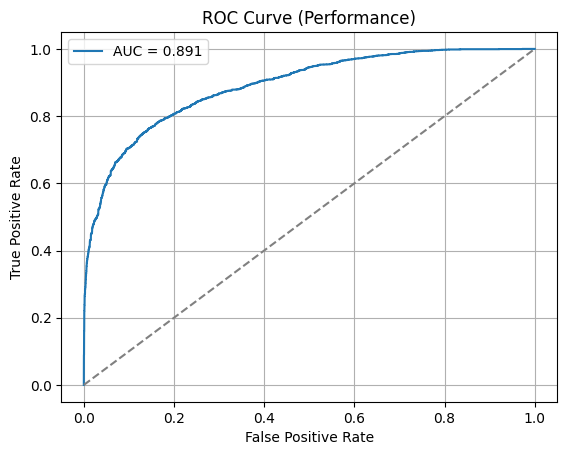

In [18]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Performance)")
plt.legend()

plt.grid()
plt.show()

### Findings

Our model achieved an accuracy of **83.85%** and a very strong **AUC of 0.891**. This suggests that the neural network is highly effective at identifying subtle indicators of cancellation. Compared to a standard logistic regression, which often struggles with dense, multi-variable datasets like this one, the MLP's ability to rebalance weights through its hidden layers allowed it to parse the information more effectively. This confirms that the deep learning approach is well-suited for high-dimensional behavioral data.